# Userbase Modelling

In [6]:
import glob
import pandas as pd


models_of_interest = ["apertus-8b-instruct","apertus-70b-instruct"]

moi = models_of_interest[1]
# 1. Collect files
files = glob.glob("../../data/litellm/public.LiteLLM_SpendLogs/1/*.parquet")


df_list = []
for file in files:
    temp_df = pd.read_parquet(file)
    temp_df = temp_df[temp_df["model"] == moi]
    temp_df = temp_df[temp_df["status"] == "success"]

    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# 2. Define the columns you want to KEEP
keep_cols = [
    "end_user",
    "startTime",
    "endTime",
    "completionStartTime",
    "prompt_tokens",
    "completion_tokens",
    "total_tokens",
]

# Keep ONLY those (ignore missing if any file doesn't have it)
df = df[[c for c in keep_cols if c in df.columns]].copy()

# 3. Parse timestamps and sort
df["startTime"] = pd.to_datetime(df["startTime"],format = "mixed")
df = df.sort_values("startTime")

df["endTime"] = pd.to_datetime(df["endTime"],format = "mixed")
df["completionStartTime"] = pd.to_datetime(df["completionStartTime"],format = "mixed")
df["processTime"] = (df["completionStartTime"] - df["startTime"]).dt.seconds

# 4. Compute inter-arrival times (Δ between current and previous request)
df["interarrival_seconds"] = df["startTime"].diff().dt.total_seconds()


print(df.shape)
df.tail() ## no day is multiple times since it starts 02.09. and ends 01.10. so its exactly one month




(103729, 9)


,end_user,startTime,endTime,completionStartTime,prompt_tokens,completion_tokens,total_tokens,processTime,interarrival_seconds
103724,enduser_eb40d354,2025-10-01 03:27:12.190,2025-10-01 03:27:14.188,2025-10-01 03:27:12.363,773,86,859,0,63.785
103725,enduser_a22bfe8e,2025-10-01 03:31:09.197,2025-10-01 03:31:35.581,2025-10-01 03:31:09.371,785,1191,1976,0,237.007
103726,enduser_583ba19e,2025-10-01 03:31:44.785,2025-10-01 03:32:54.597,2025-10-01 03:31:45.109,1897,3052,4949,0,35.588
103727,enduser_d41d8cd9,2025-10-01 03:31:52.958,2025-10-01 03:32:04.954,2025-10-01 03:32:04.953,1216,537,1753,11,8.173
103728,enduser_d41d8cd9,2025-10-01 03:33:23.783,2025-10-01 03:33:34.514,2025-10-01 03:33:34.514,1119,500,1619,10,90.825


## Tokens Generation Analysis

Log-normal fit: mu = 7.1873573627442155 sigma = 1.0855094430981018


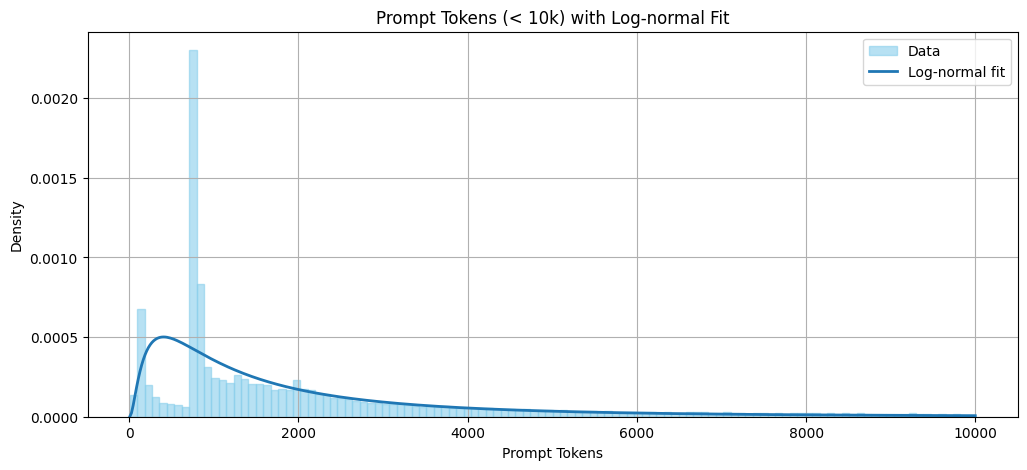

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import lognorm

# --- Filtered data ---
prompt_all = df["prompt_tokens"].dropna()
prompt_lt_15k = prompt_all[(prompt_all < 10000) & (prompt_all > 0)]

# --- Fit log-normal ---
# lognorm takes shape (sigma), loc, scale=exp(mu)
shape, loc, scale = lognorm.fit(prompt_lt_15k, floc=0)

mu = np.log(scale)
sigma = shape
print("Log-normal fit: mu =", mu, "sigma =", sigma)

# --- Prepare PDF for overlay ---
x = np.linspace(prompt_lt_15k.min(), prompt_lt_15k.max(), 500)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)

# --- Plot ---
plt.figure(figsize=(12, 5))

# Histogram
plt.hist(prompt_lt_15k, bins="fd", density=True,
         alpha=0.6, color="skyblue", edgecolor="skyblue", label="Data")

# Log-normal fit
plt.plot(x, pdf, linewidth=2, label="Log-normal fit")

plt.title("Prompt Tokens (< 10k) with Log-normal Fit")
plt.xlabel("Prompt Tokens")
plt.ylabel("Density")
plt.grid(True)
plt.legend()

plt.show()


Log-normal fit: mu = 6.507073088236288 sigma = 1.1851349638697206


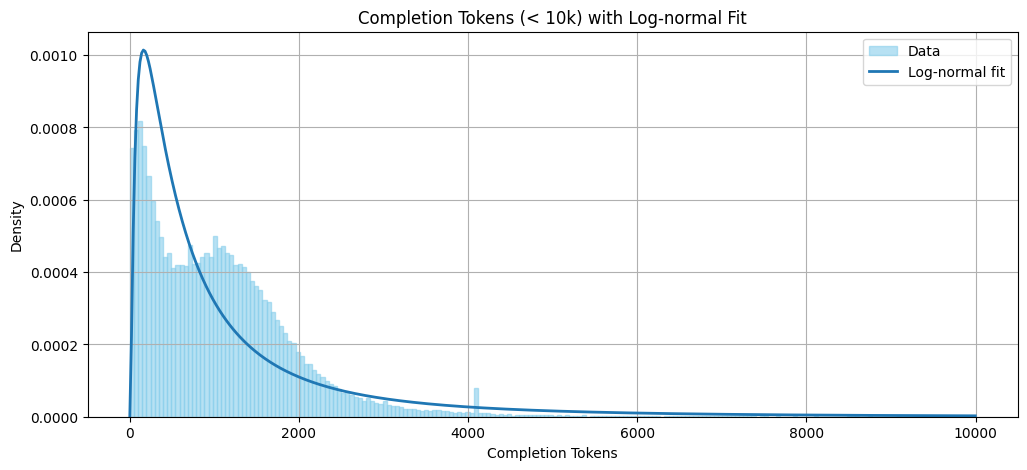

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import lognorm

# --- Filtered data ---
completion_all = df["completion_tokens"].dropna()
completion_lt_15k = completion_all[(completion_all < 10000) & (completion_all > 0)]  # remove zeros

# --- Fit log-normal ---
# lognorm takes shape (sigma), loc, scale=exp(mu)
shape, loc, scale = lognorm.fit(completion_lt_15k, floc=0)

mu = np.log(scale)
sigma = shape
print("Log-normal fit: mu =", mu, "sigma =", sigma)

# --- Prepare PDF for overlay ---
x = np.linspace(completion_lt_15k.min(), completion_lt_15k.max(), 500)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)

# --- Plot ---
plt.figure(figsize=(12, 5))

# Histogram
plt.hist(completion_lt_15k, bins="fd", density=True,
         alpha=0.6, color="skyblue", edgecolor="skyblue", label="Data")

# Log-normal fit
plt.plot(x, pdf, linewidth=2, label="Log-normal fit")

plt.title("Completion Tokens (< 10k) with Log-normal Fit")
plt.xlabel("Completion Tokens")
plt.ylabel("Density")
plt.grid(True)
plt.legend()

plt.show()


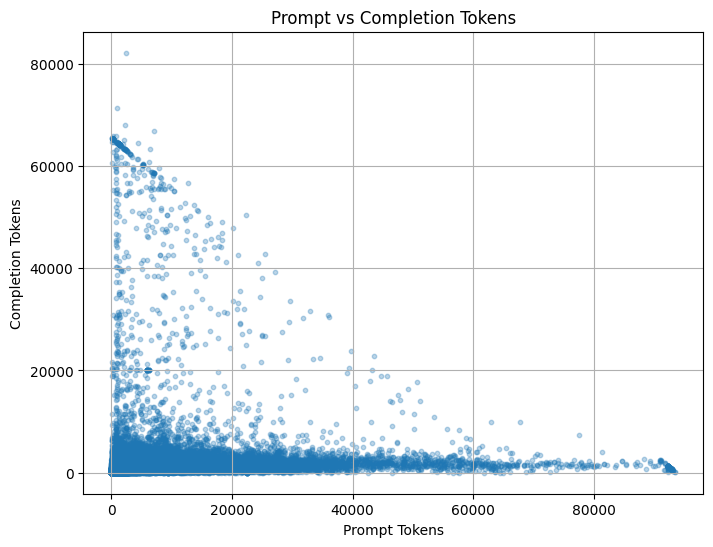

In [9]:
import matplotlib.pyplot as plt

prompt = df["prompt_tokens"].dropna()
completion = df["completion_tokens"].dropna()

# Align indices in case of missing rows
prompt, completion = prompt.align(completion, join="inner")

plt.figure(figsize=(8, 6))
plt.scatter(prompt, completion, alpha=0.3, s=10)

plt.xlabel("Prompt Tokens")
plt.ylabel("Completion Tokens")
plt.title("Prompt vs Completion Tokens")
plt.grid(True)
plt.show()


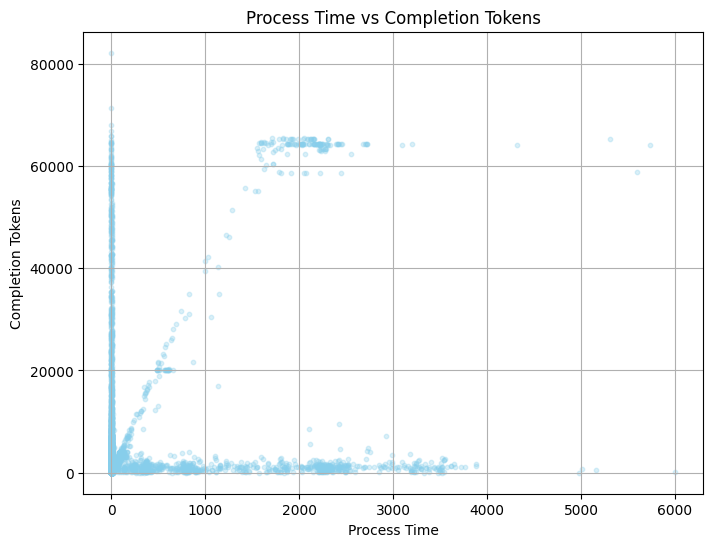

In [10]:
import matplotlib.pyplot as plt

# Drop missing values
df_clean = df[['processTime', 'completion_tokens']].dropna()

plt.figure(figsize=(8, 6))
plt.scatter(df_clean['processTime'], df_clean['completion_tokens'],
            alpha=0.3, s=10, color='skyblue')

plt.xlabel("Process Time")
plt.ylabel("Completion Tokens")
plt.title("Process Time vs Completion Tokens")
plt.grid(True)
plt.show()


Rows after filtering zeros: 7022
Log-normal fit parameters:
  mu    = 6.80097628706551
  sigma = 1.1505691513680176


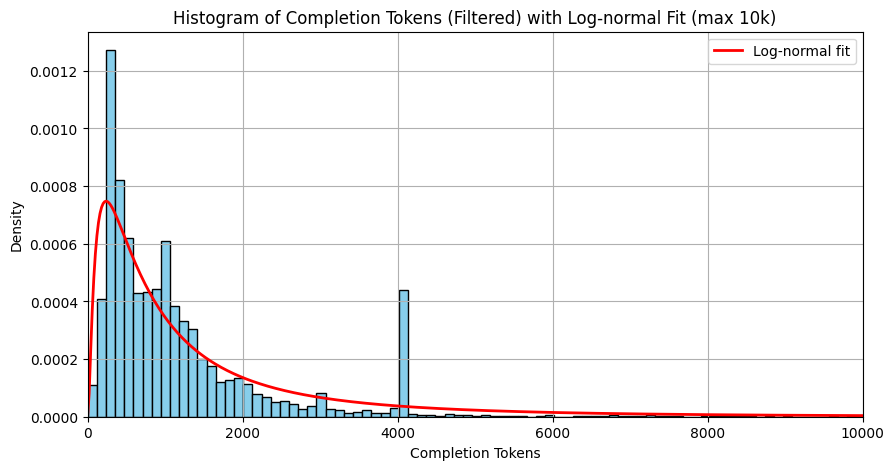

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# --- Step 1: Filter the dataframe ---
mask = ((df['processTime'] > 5))
df_filtered = df[mask].copy()

# --- Step 2: Extract completion tokens and remove zeros ---
completion = df_filtered['completion_tokens'].dropna()
completion = completion[completion > 0]  # remove zeros

print(f"Rows after filtering zeros: {len(completion)}")

# --- Step 3: Fit log-normal distribution (use all values) ---
shape, loc, scale = lognorm.fit(completion, floc=0)
mu = np.log(scale)
sigma = shape
print("Log-normal fit parameters:")
print("  mu    =", mu)
print("  sigma =", sigma)

# --- Step 4: Plot histogram + log-normal fit ---
plt.figure(figsize=(10, 5))

# Histogram (density) with bins
plt.hist(completion, bins="fd", density=True, color='skyblue', edgecolor='black')

# PDF overlay (also limited to 10k)
x = np.linspace(completion.min(), min(completion.max(), 10000), 500)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, pdf, 'r-', linewidth=2, label='Log-normal fit')

plt.title("Histogram of Completion Tokens (Filtered) with Log-normal Fit (max 10k)")
plt.xlabel("Completion Tokens")
plt.ylabel("Density")
plt.xlim(0, 10000)  # <-- limit x-axis
plt.grid(True)
plt.legend()
plt.show()


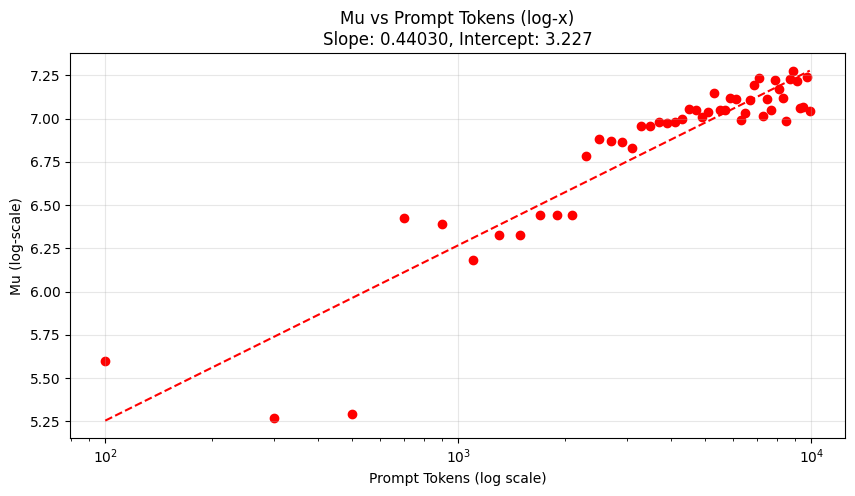

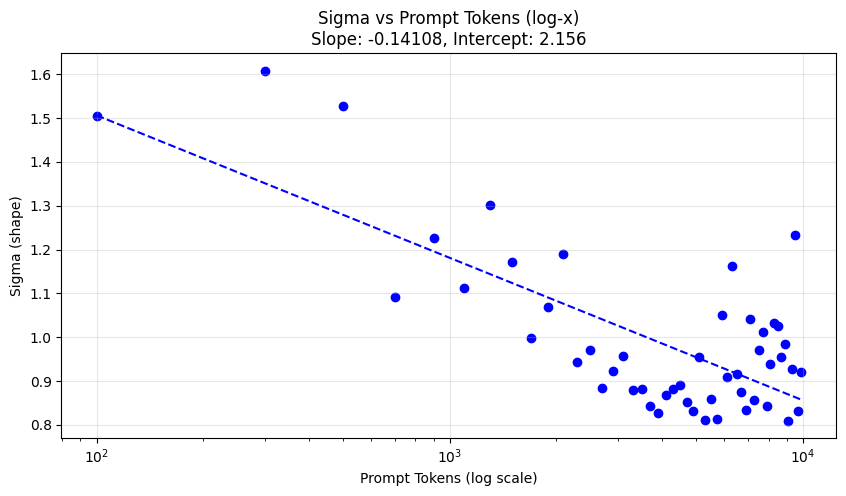

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

# --- Filter and drop invalid values ---
prompt = df['prompt_tokens'].dropna()
completion = df['completion_tokens'].dropna()
prompt, completion = prompt.align(completion, join='inner')

# Keep only positive tokens and prompt tokens <= 10000
mask_valid = (prompt > 0) & (prompt <= 10000) & (completion > 0)
prompt = prompt[mask_valid]
completion = completion[mask_valid]

# --- Bin prompts in 200-token ranges ---
bin_width = 200
max_prompt = 10000
bin_edges = np.arange(0, max_prompt + bin_width, bin_width)
bin_centers = bin_edges[:-1] + bin_width/2

mus = []
sigmas = []

for low, high in zip(bin_edges[:-1], bin_edges[1:]):
    mask_bin = (prompt >= low) & (prompt < high)
    comp_bin = completion[mask_bin]
    
    if len(comp_bin) < 5:
        mus.append(np.nan)
        sigmas.append(np.nan)
        continue
    
    # Fit log-normal
    shape, loc, scale = lognorm.fit(comp_bin, floc=0)
    mu = np.log(scale)
    
    mus.append(mu)
    sigmas.append(shape)

# Convert to arrays and filter valid bins
mus = np.array(mus)
sigmas = np.array(sigmas)
valid_mask = ~np.isnan(mus)
bin_centers_valid = bin_centers[valid_mask]

# --- Linear regression for mu ---
slope_mu, intercept_mu, _, _, _ = linregress(np.log(bin_centers_valid), mus[valid_mask])

plt.figure(figsize=(10, 5))
plt.scatter(bin_centers_valid, mus[valid_mask], color='red')
plt.plot(bin_centers_valid, intercept_mu + slope_mu*np.log(bin_centers_valid), color='red', linestyle='--')
plt.xscale('log')
plt.xlabel("Prompt Tokens (log scale)")
plt.ylabel("Mu (log-scale)")
plt.title(f"Mu vs Prompt Tokens (log-x)\nSlope: {slope_mu:.5f}, Intercept: {intercept_mu:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

# --- Linear regression for sigma ---
slope_sigma, intercept_sigma, _, _, _ = linregress(np.log(bin_centers_valid), sigmas[valid_mask])

plt.figure(figsize=(10, 5))
plt.scatter(bin_centers_valid, sigmas[valid_mask], color='blue')
plt.plot(bin_centers_valid, intercept_sigma + slope_sigma*np.log(bin_centers_valid), color='blue', linestyle='--')
plt.xscale('log')
plt.xlabel("Prompt Tokens (log scale)")
plt.ylabel("Sigma (shape)")
plt.title(f"Sigma vs Prompt Tokens (log-x)\nSlope: {slope_sigma:.5f}, Intercept: {intercept_sigma:.3f}")
plt.grid(True, alpha=0.3)
plt.show()


#### Proposed Trend

$\sigma = \max(-0.145*\log(x)  + 2.4,0.01)$

$\log(\mu) = \min(0.42*\log(x) + 3.2)$


We compare to the real data below. Note that even small changes to the coefficients can have big impacs, as for $\mu$ for example, we are working wtih the log version

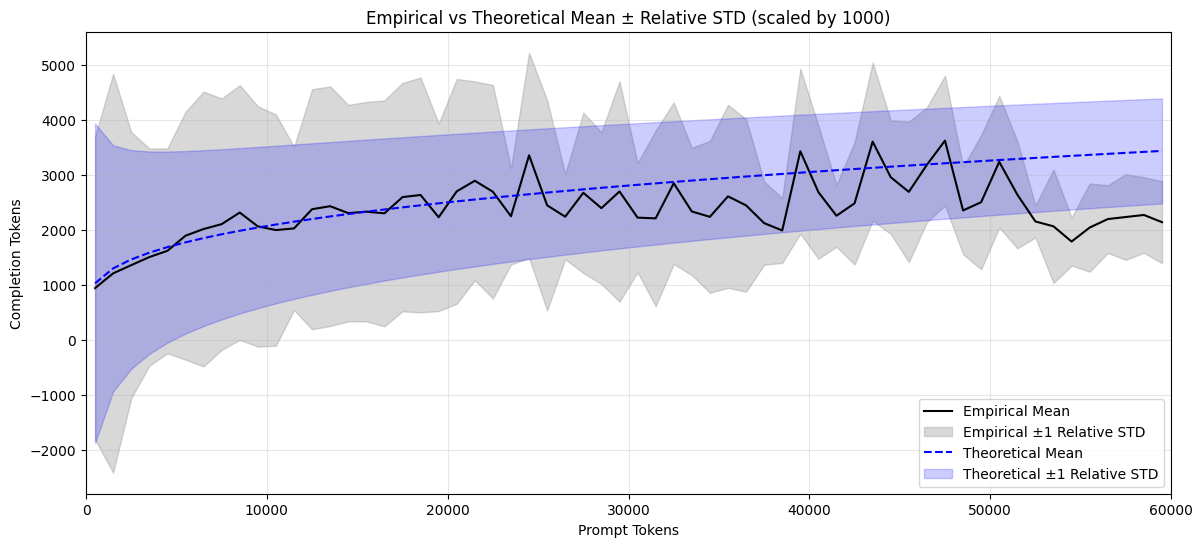

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Filter valid data ---
prompt = df['prompt_tokens'].dropna()
completion = df['completion_tokens'].dropna()
prompt, completion = prompt.align(completion, join='inner')

mask_valid = (prompt > 0) & (completion > 0)
prompt = prompt[mask_valid]
completion = completion[mask_valid]

# --- Define bins (1000 tokens) ---
bin_edges = np.arange(0, 61000, 1000)  # 0, 1000, ..., 60k
bin_centers = bin_edges[:-1] + 500  # center of each bin

# --- Empirical mean and relative std ---
means = []
stds = []

for low, high in zip(bin_edges[:-1], bin_edges[1:]):
    mask_bin = (prompt >= low) & (prompt < high)
    comp_bin = completion[mask_bin]
    
    if len(comp_bin) == 0:
        means.append(np.nan)
        stds.append(np.nan)
        continue
    
    means.append(np.mean(comp_bin))
    stds.append(np.std(comp_bin))

means = np.array(means)
stds = np.array(stds)
rel_std_empirical = stds / means

# --- Theoretical mu and sigma trends ---
log_bin_centers = np.log(bin_centers + 1e-6)  # avoid log(0)

sigma_theoretical = np.maximum(-0.145*log_bin_centers + 2.4, 0.01)
mu_theoretical = 0.42*log_bin_centers + 3.2  # log-space mean

# --- Theoretical mean and relative std ---
mean_theoretical = np.exp(mu_theoretical + sigma_theoretical**2 / 2)
rel_std_theoretical = np.sqrt(np.exp(sigma_theoretical**2) - 1)

# --- Plot with fixed scale for relative std ---
SCALE = 1000  # fixed scaling factor for visualization

plt.figure(figsize=(14, 6))

# Empirical
plt.plot(bin_centers, means, color='black', label='Empirical Mean')
plt.fill_between(bin_centers, means - rel_std_empirical*SCALE, means + rel_std_empirical*SCALE,
                 color='gray', alpha=0.3, label='Empirical ±1 Relative STD')

# Theoretical
plt.plot(bin_centers, mean_theoretical, color='blue', linestyle='--', label='Theoretical Mean')
plt.fill_between(bin_centers, mean_theoretical - rel_std_theoretical*SCALE, mean_theoretical + rel_std_theoretical*SCALE,
                 color='blue', alpha=0.2, label='Theoretical ±1 Relative STD')

plt.xlabel("Prompt Tokens")
plt.ylabel("Completion Tokens")
plt.title(f"Empirical vs Theoretical Mean ± Relative STD (scaled by {SCALE})")
plt.grid(True, alpha=0.3)
plt.xlim(0, 60000)
plt.legend()
plt.show()


## Arrival Times Analysis

Daytime λ: 0.300  (mean interarrival 3.335s)
Nighttime λ: 0.242  (mean interarrival 4.124s)


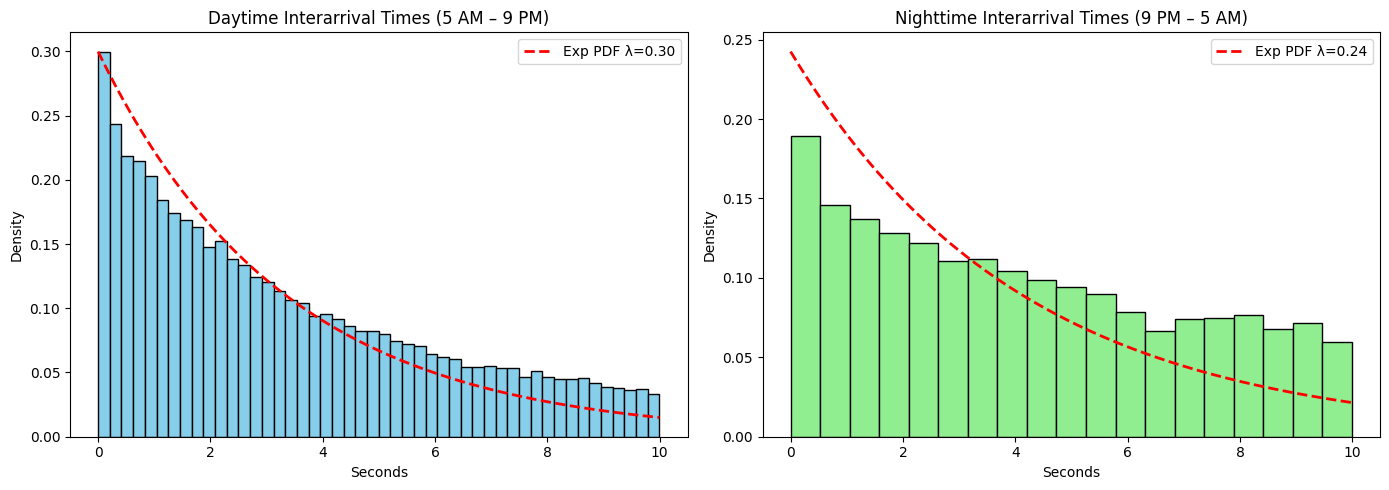

In [14]:
import matplotlib.pyplot as plt

# --- Ensure hour column exists ---
df["hour"] = df["startTime"].dt.hour

# --- Define masks for day/night ---
day_mask = (df["hour"] >= 5) & (df["hour"] < 21)   # 5 AM ≤ hour < 9 PM
night_mask = ~day_mask                              

# --- Filter interarrival times ---
inter_day   = df.loc[day_mask, "interarrival_seconds"].dropna()
inter_night = df.loc[night_mask, "interarrival_seconds"].dropna()

# Optional: remove extreme outliers for plotting
inter_day   = inter_day[inter_day < 10]    # seconds
inter_night = inter_night[inter_night < 10]

# --- Fit lambda (rate) ---
lambda_day   = 1 / inter_day.mean()
lambda_night = 1 / inter_night.mean()

# --- Plot side-by-side histograms ---
print(f"Daytime λ: {lambda_day:.3f}  (mean interarrival {inter_day.mean():.3f}s)")
print(f"Nighttime λ: {lambda_night:.3f}  (mean interarrival {inter_night.mean():.3f}s)")

# --- Plot histograms with fitted exponential PDFs ---
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Daytime
counts, bins, _ = axes[0].hist(inter_day, bins="fd", color='skyblue', edgecolor='black', density=True)
x = np.linspace(0, bins.max(), 200)
pdf_day = lambda_day * np.exp(-lambda_day * x)
axes[0].plot(x, pdf_day, 'r--', lw=2, label=f"Exp PDF λ={lambda_day:.2f}")
axes[0].set_title("Daytime Interarrival Times (5 AM – 9 PM)")
axes[0].set_xlabel("Seconds")
axes[0].set_ylabel("Density")
axes[0].legend()

# Nighttime
counts, bins, _ = axes[1].hist(inter_night, bins="fd", color='lightgreen', edgecolor='black', density=True)
x = np.linspace(0, bins.max(), 200)
pdf_night = lambda_night * np.exp(-lambda_night * x)
axes[1].plot(x, pdf_night, 'r--', lw=2, label=f"Exp PDF λ={lambda_night:.2f}")
axes[1].set_title("Nighttime Interarrival Times (9 PM – 5 AM)")
axes[1].set_xlabel("Seconds")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import ks_2samp, mannwhitneyu

stat, p_value = ks_2samp(inter_day, inter_night)
print(f"KS statistic: {stat:.3f}, p-value: {p_value:.3e}")

stat, p_value = mannwhitneyu(inter_day, inter_night, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.3f}, p-value: {p_value:.3e}")

KS statistic: 0.126, p-value: 1.381e-71
Mann-Whitney U statistic: 139207500.000, p-value: 6.434e-86


#### Interarrival Time As a function of Time

 - clearly the behavior is different for different times of the day, as expected. 
 - it is useful to draft a probability distribution of when the arrival happens in the 24 hours time window
 - this allows us to not model the process using exponential interarrival time disti=ribution, but we can just assume we have X number of requests - more tangible and easier to predict as a common business employee, and we just randomly arrange them in the 24 hour interval
 - other option would be to use the gamma distribution


C:\Users\lukas\AppData\Local\Temp\ipykernel_3080\2868606672.py:18: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  bin_edges = pd.date_range(start=day_start, end=day_end, freq='60T')


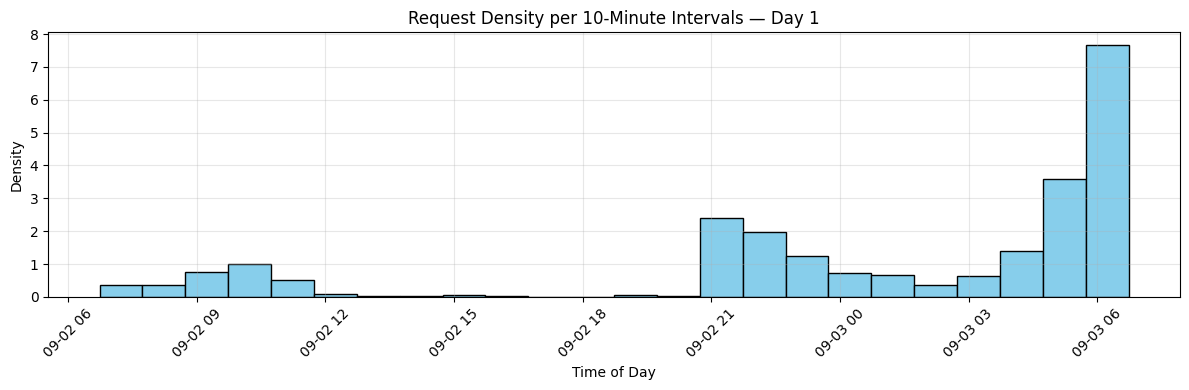

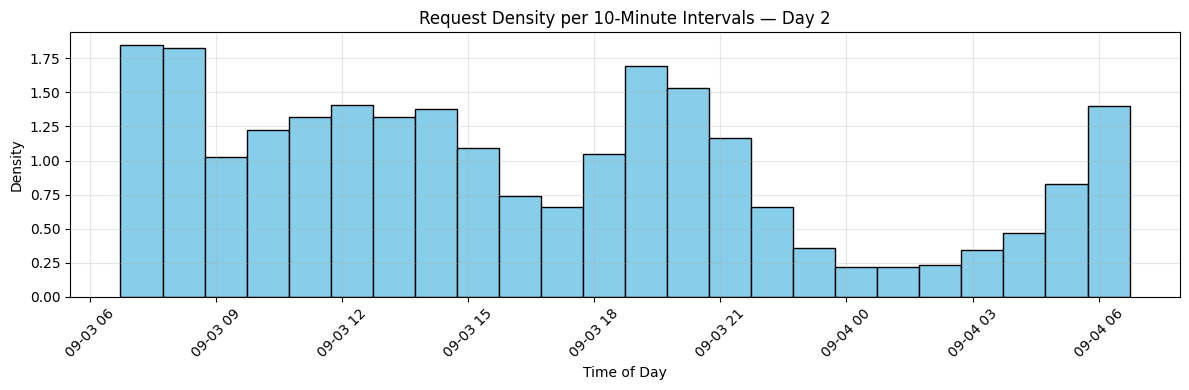

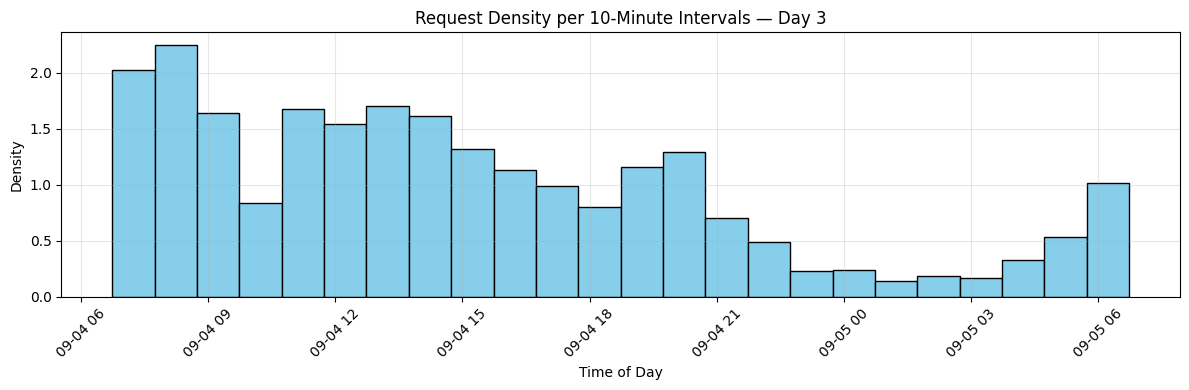

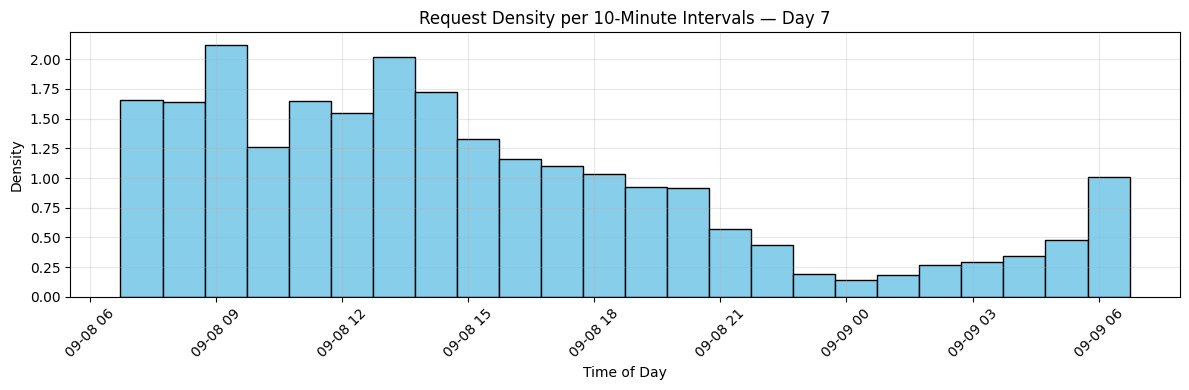

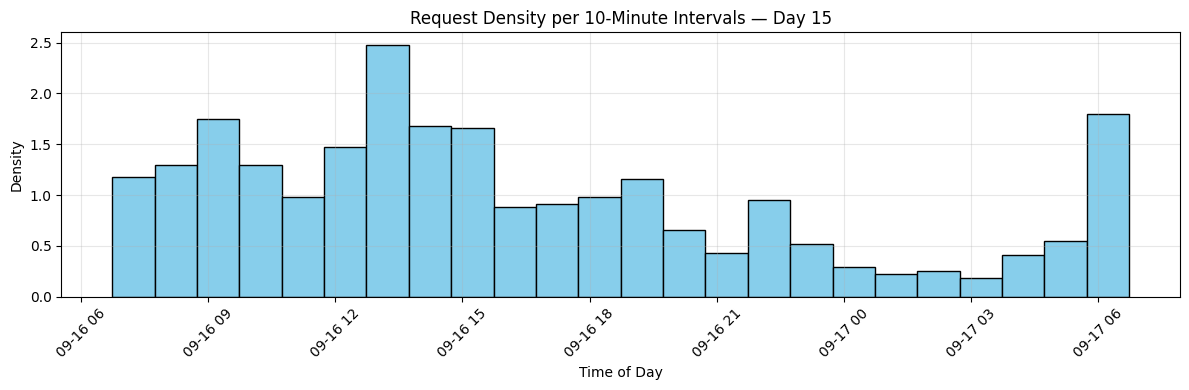

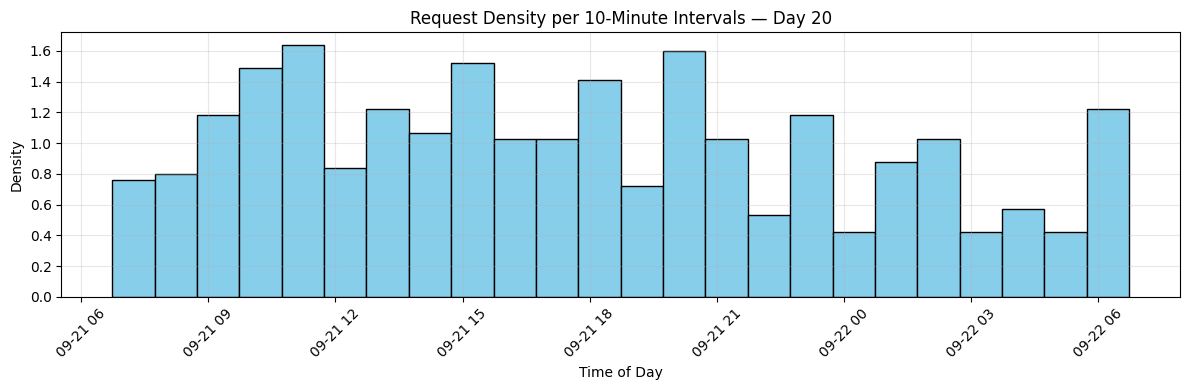

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Ensure startTime is datetime ---
df['startTime'] = pd.to_datetime(df['startTime'])

# --- Days to plot ---
days_to_plot = [1, 2, 3, 7, 15, 20]  # first, second, third, 7th, 15th, 30th

for day in days_to_plot:
    # Filter for this day
    day_start = df['startTime'].min() + pd.Timedelta(days=day-1)
    day_end = day_start + pd.Timedelta(days=1)
    df_day = df[(df['startTime'] >= day_start) & (df['startTime'] < day_end)]
    
    # 10-minute bins
    bin_edges = pd.date_range(start=day_start, end=day_end, freq='60T')
    
    # Histogram
    plt.figure(figsize=(12,4))
    plt.hist(df_day['startTime'], bins=bin_edges, density=True, color='skyblue', edgecolor='black')
    
    plt.xlabel("Time of Day")
    plt.ylabel("Density")
    plt.title(f"Request Density per 10-Minute Intervals — Day {day}")
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Fitted Von Mises: kappa=0.62, loc=-3.12 rad (~-11.93 h)


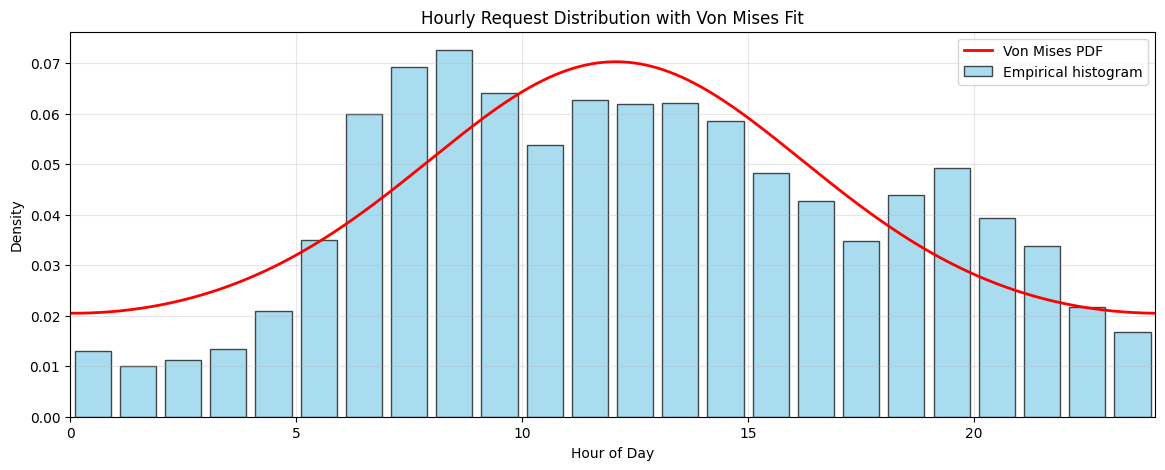

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises

# --- Ensure startTime is datetime ---
df['startTime'] = pd.to_datetime(df['startTime'])

# --- Convert times to hours with fractions of seconds ---
hours = df['startTime'].dt.hour + df['startTime'].dt.minute/60 + df['startTime'].dt.second/3600

# --- Histogram: hourly bins ---
bin_edges = np.arange(0, 25, 1)  # 0-24 hours, 1-hour bins
counts, bins = np.histogram(hours, bins=bin_edges, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- Convert hours to radians for Von Mises ---
angles = hours / 24 * 2 * np.pi

# --- Fit Von Mises ---
kappa, loc, _ = vonmises.fit(angles, fscale=1)
print(f"Fitted Von Mises: kappa={kappa:.2f}, loc={loc:.2f} rad (~{loc/(2*np.pi)*24:.2f} h)")

# --- Overlay PDF: very fine resolution (e.g., every 0.01 s) ---
# 24 hours = 86400 s, so step = 0.01 s → 8.64e6 points
# To avoid huge arrays, let's do 0.1 s resolution (~864,000 points)
seconds_per_day = 24*3600
step = 0.1  # seconds
x_seconds = np.arange(0, seconds_per_day, step)
x_hours = x_seconds / 3600  # convert to hours
x_radians = x_hours / 24 * 2 * np.pi

pdf = vonmises.pdf(x_radians, kappa, loc=loc)

# --- Plot ---
# Convert PDF from radians → hours
pdf_hours = pdf * (2*np.pi/24)

plt.figure(figsize=(14,5))
plt.bar(bin_centers, counts, width=0.8, color='skyblue', edgecolor='black', alpha=0.7, label='Empirical histogram')
plt.plot(x_hours, pdf_hours, color='red', lw=2, label='Von Mises PDF')
plt.xlabel("Hour of Day")
plt.ylabel("Density")
plt.title("Hourly Request Distribution with Von Mises Fit")
plt.grid(True, alpha=0.3)
plt.xlim(0, 24)
plt.legend()
plt.show()



### Proposed Von Mises Distribution

$peak\_hour = 12$ so $loc = 2*pi*peak\_hour/24$

$\kappa = 0.65$ This parameter is harder to interpret, but tells how concetrated is the peak

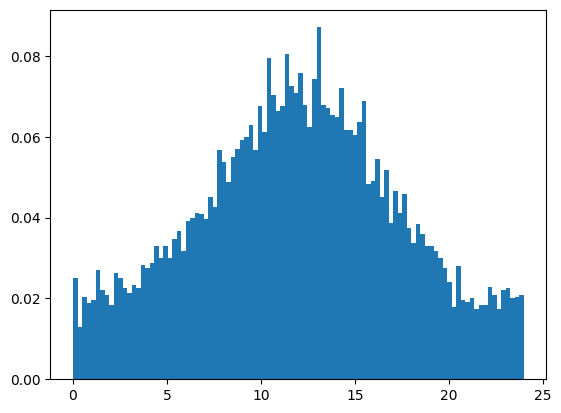

In [18]:
from scipy.stats import vonmises
import numpy as np

# --- Parameters ---
peak_hour = 12       # peak at 6:30 AM
kappa = 0.65           # concentration

# Convert peak hour to radians (0–24h → 0–2π)
loc = peak_hour / 24 * 2 * np.pi

# Sample N points from Von Mises
N = 10000
samples_rad = vonmises.rvs(kappa=kappa, loc=loc, size=N)

# Wrap to 0–2π just in case
samples_rad = samples_rad % (2 * np.pi)

# Convert back to hours
samples_hours = samples_rad / (2 * np.pi) * 24

# Print first 10 samples
plt.hist(samples_hours,bins = 100,density = True)
plt.show()


## User Analysis


We want a simple user analysis, we will use just completion tokens, prompt tokens, and number of requests. We will do so for each day separately.
We do not care about when they prompt the model, as this is absorbed into the arrival tyma analysis, we just want to estimate how bad can user behavior get. This allows us to omit modelling the user behavior in asense of when - they have sessions - preferred times when to prompt, etc... We model this using the time dependent arrival time distribution. We only care about the usage -  how many prompts and how many primpt and completion tokens.

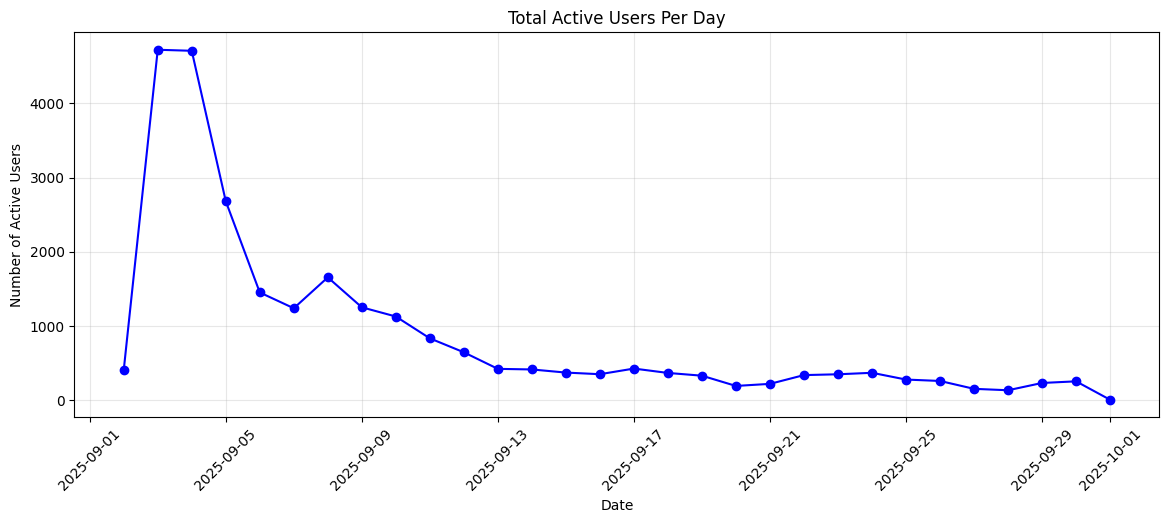

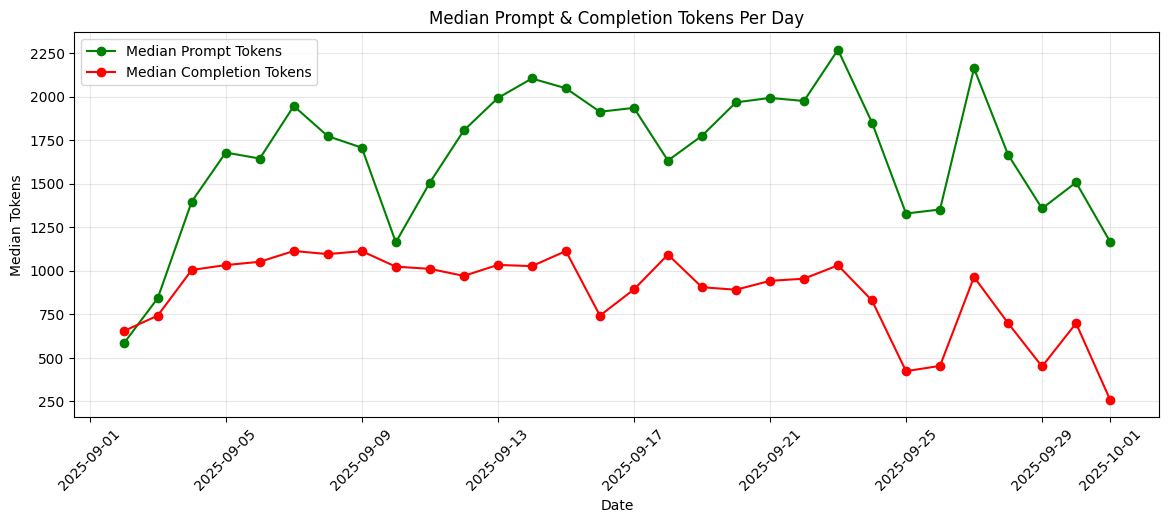

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Ensure startTime is datetime ---
df['startTime'] = pd.to_datetime(df['startTime'])

# --- Add a date column ---
df['date'] = df['startTime'].dt.date

# --- 1️⃣ Total active users per day ---
users_per_day = df.groupby('date')['end_user'].nunique()  # assumes you have 'user_id' column

plt.figure(figsize=(14,5))
plt.plot(users_per_day.index, users_per_day.values, marker='o', color='blue')
plt.xlabel("Date")
plt.ylabel("Number of Active Users")
plt.title("Total Active Users Per Day")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# --- 2️⃣ Median prompt and completion tokens per day ---
median_tokens = df.groupby('date').agg({
    'prompt_tokens': 'median',
    'completion_tokens': 'median'
})

plt.figure(figsize=(14,5))
plt.plot(median_tokens.index, median_tokens['prompt_tokens'], marker='o', color='green', label='Median Prompt Tokens')
plt.plot(median_tokens.index, median_tokens['completion_tokens'], marker='o', color='red', label='Median Completion Tokens')
plt.xlabel("Date")
plt.ylabel("Median Tokens")
plt.title("Median Prompt & Completion Tokens Per Day")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


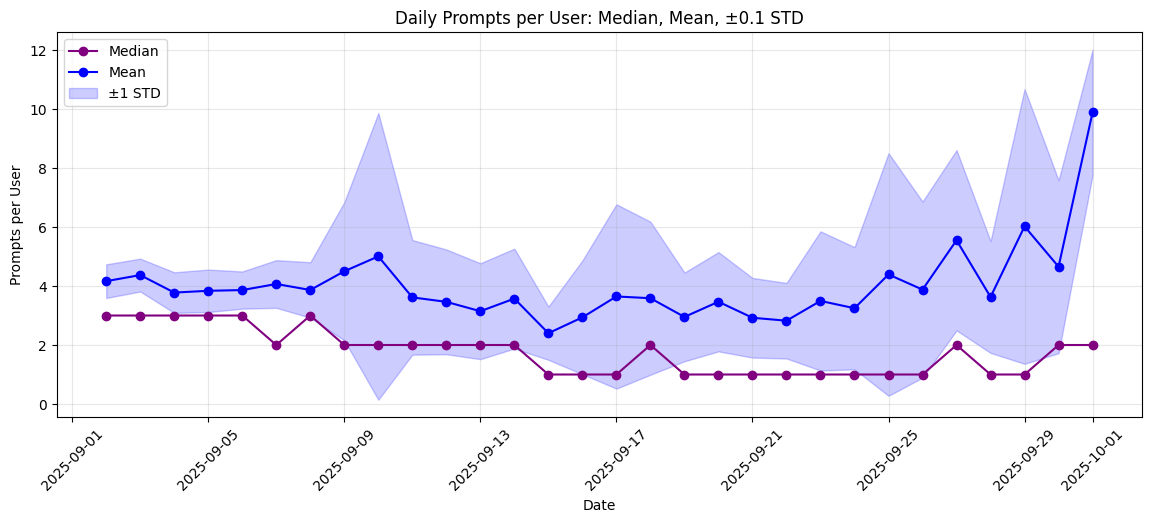

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


mul = 0.1
# --- Ensure startTime is datetime ---
df['startTime'] = pd.to_datetime(df['startTime'])
df['date'] = df['startTime'].dt.date

# --- Prompts per user per day ---
prompts_per_user_day = df.groupby(['date', 'end_user']).size().reset_index(name='num_prompts')

# --- Daily statistics ---
stats = prompts_per_user_day.groupby('date')['num_prompts'].agg(['median','mean','std'])
stats['upper'] = stats['mean'] + mul*stats['std']
stats['lower'] = stats['mean'] - mul*stats['std']

# --- Plot ---
plt.figure(figsize=(14,5))
plt.plot(stats.index, stats['median'], marker='o', color='purple', label='Median')
plt.plot(stats.index, stats['mean'], marker='o', color='blue', label='Mean')
plt.fill_between(stats.index, stats['lower'], stats['upper'], color='blue', alpha=0.2, label='±1 STD')

plt.xlabel("Date")
plt.ylabel("Prompts per User")
plt.title(f"Daily Prompts per User: Median, Mean, ±{mul} STD")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


#### Dependence on time
It can be assumed that per prompt behavior does not change over time - people od not start to, out of nowhere write longer prompts, etc...
However, during model launch, your users will prompt the model more often.

Prompts per user meduan wise ge tlower, mean wise not really, higher even, but this is quite unusual, i would assumt that there was some model promotion again - some event - can be treated as model launch, or devs were experimenting with the model.

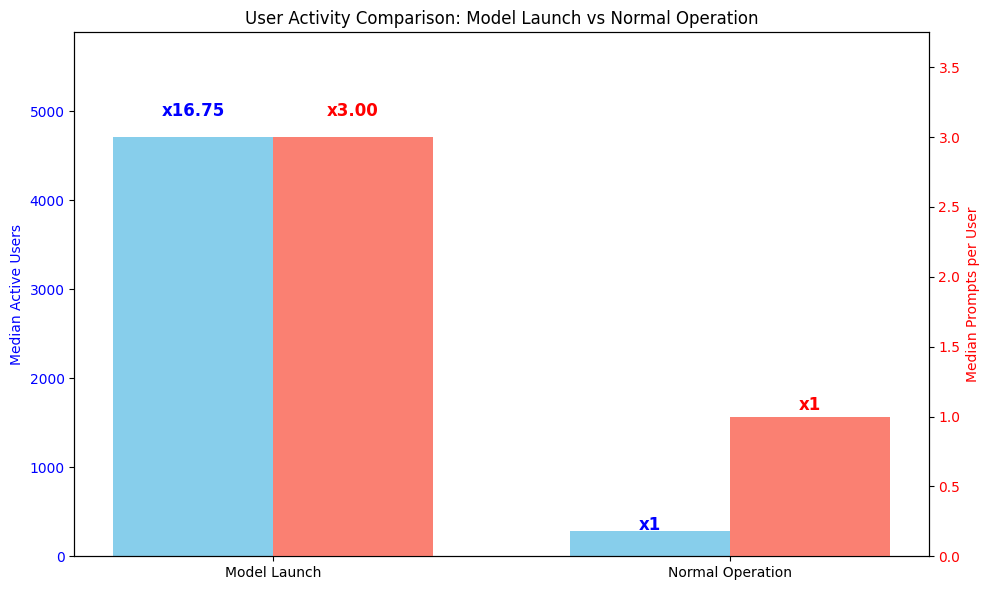

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure startTime is datetime ---
df['startTime'] = pd.to_datetime(df['startTime'])
df['date'] = df['startTime'].dt.date

# --- Define date ranges ---
launch_days = pd.date_range("2025-09-02", "2025-09-04").date
normal_days = pd.date_range("2025-09-15", "2026-09-22").date

# --- Split data ---
df_launch = df[df['date'].isin(launch_days)]
df_normal = df[df['date'].isin(normal_days)]

# --- Median active users per day ---
users_launch_median = df_launch.groupby('date')['end_user'].nunique().median()
users_normal_median = df_normal.groupby('date')['end_user'].nunique().median()

# --- Median prompts per user per day ---
prompts_per_user_launch = df_launch.groupby(['date','end_user']).size().reset_index(name='num_prompts')
median_prompts_launch = prompts_per_user_launch.groupby('date')['num_prompts'].median().median()

prompts_per_user_normal = df_normal.groupby(['date','end_user']).size().reset_index(name='num_prompts')
median_prompts_normal = prompts_per_user_normal.groupby('date')['num_prompts'].median().median()

# --- Period names ---
periods = ['Model Launch', 'Normal Operation']

# --- Prepare values ---
active_users = [users_launch_median, users_normal_median]
median_prompts = [median_prompts_launch, median_prompts_normal]

# --- Compute multipliers ---
ratio_users = users_launch_median / users_normal_median
ratio_prompts = median_prompts_launch / median_prompts_normal

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10,6))
width = 0.35
x = range(len(periods))

# Active users bars
ax1.bar([p - width/2 for p in x], active_users, width=width, color='skyblue', label='Active Users')
ax1.set_ylabel("Median Active Users", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Median prompts bars
ax2 = ax1.twinx()
ax2.bar([p + width/2 for p in x], median_prompts, width=width, color='salmon', label='Median Prompts/User')
ax2.set_ylabel("Median Prompts per User", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- Adjust y-limits so multipliers fit above bars ---
ax1.set_ylim(0, max(active_users)*1.25)
ax2.set_ylim(0, max(median_prompts)*1.25)

# Multipliers above bars
ax1.text(x=0 - width/2, y=active_users[0]*1.05, s=f"x{ratio_users:.2f}", ha='center', color='blue', fontsize=12, fontweight='bold')
ax1.text(x=1 - width/2, y=active_users[1]*1.05, s="x1", ha='center', color='blue', fontsize=12, fontweight='bold')

ax2.text(x=0 + width/2, y=median_prompts[0]*1.05, s=f"x{ratio_prompts:.2f}", ha='center', color='red', fontsize=12, fontweight='bold')
ax2.text(x=1 + width/2, y=median_prompts[1]*1.05, s="x1", ha='center', color='red', fontsize=12, fontweight='bold')

# Formatting
plt.xticks(x, periods)
plt.title("User Activity Comparison: Model Launch vs Normal Operation")
fig.tight_layout()
plt.show()


### Studying Types of Users

If we want to take assumptions on how much will our users use our model, we need to see what kind of users we have, for both model operation,  and model launch.


Model Launch: Best silhouette score 0.696 for k=3

Model Launch Cluster Summary (clusters as columns):
cluster                       0         1        2
median_prompts_per_day     3.24     11.09     6.03
median_prompt_tokens     849.57  10062.98  3168.96
cluster_size            7385.00    179.00  1523.00

Normal Operation: Best silhouette score 0.767 for k=3

Normal Operation Cluster Summary (clusters as columns):
cluster                       0         1        2
median_prompts_per_day     1.74      3.59     3.18
median_prompt_tokens    1711.75  23161.21  8807.97
cluster_size            2903.00     49.00   456.00


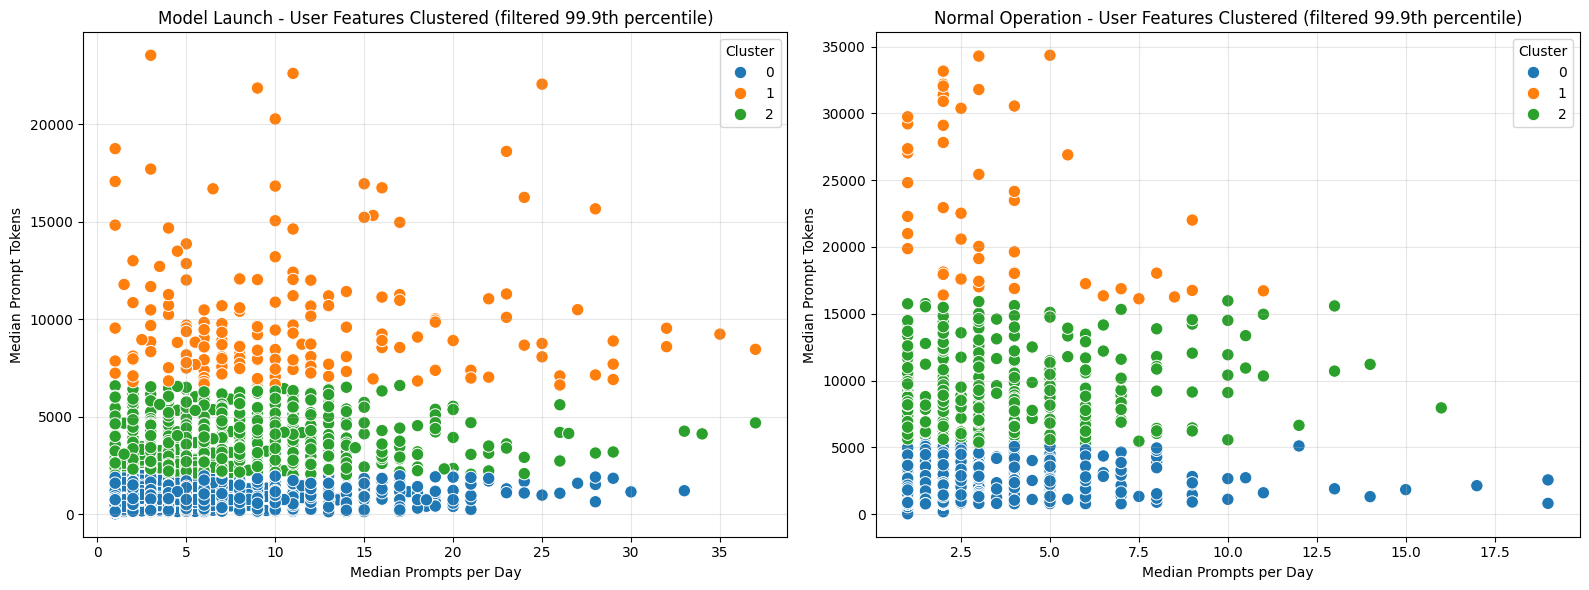

In [22]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Ensure startTime is datetime ---
df['startTime'] = pd.to_datetime(df['startTime'])
df['date'] = df['startTime'].dt.date

# --- Define date ranges ---
launch_days = pd.date_range("2025-09-02", "2025-09-04").date
normal_days = pd.date_range("2025-09-15", "2026-09-22").date

periods = {
    'Model Launch': launch_days,
    'Normal Operation': normal_days
}

results = {}

for period_name, dates in periods.items():
    df_period = df[df['date'].isin(dates)]
    
    # --- Construct user features ---
    user_features = df_period.groupby('end_user').agg(
        median_prompts_per_day=('date', lambda x: x.value_counts().median()),
        median_prompt_tokens=('prompt_tokens', 'median')
    ).reset_index()
    
    # --- Remove 99th percentile outliers ---
    p99_prompts = user_features['median_prompts_per_day'].quantile(0.999)
    p99_tokens = user_features['median_prompt_tokens'].quantile(0.999)
    user_features = user_features[
        (user_features['median_prompts_per_day'] <= p99_prompts) &
        (user_features['median_prompt_tokens'] <= p99_tokens)
    ].copy()
    
    X = user_features[['median_prompts_per_day','median_prompt_tokens']].values
    
    # --- Find best cluster using silhouette ---
    best_score = -1
    best_k = 3
    best_labels = None
    for k in range(3, 10):
        km = KMeans(n_clusters=k, random_state=42)
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
            
    user_features['cluster'] = best_labels
    print(f"\n{period_name}: Best silhouette score {best_score:.3f} for k={best_k}")
    
    # --- Cluster summary table ---
    cluster_summary = user_features.groupby('cluster').agg(
        median_prompts_per_day=('median_prompts_per_day','mean'),
        median_prompt_tokens=('median_prompt_tokens','mean'),
        cluster_size=('end_user','count')
    ).round(2)
    cluster_summary_t = cluster_summary.T
    print(f"\n{period_name} Cluster Summary (clusters as columns):")
    print(cluster_summary_t.to_string())
    
    # --- Store for plotting ---
    results[period_name] = user_features

# --- Plot side by side scatterplots of raw features ---
fig, axes = plt.subplots(1, 2, figsize=(16,6))

for ax, (period_name, user_features) in zip(axes, results.items()):
    sns.scatterplot(
        data=user_features, 
        x='median_prompts_per_day', 
        y='median_prompt_tokens', 
        hue='cluster', 
        palette='tab10', 
        s=80, 
        ax=ax
    )
    ax.set_title(f'{period_name} - User Features Clustered (filtered 99.9th percentile)')
    ax.set_xlabel('Median Prompts per Day')
    ax.set_ylabel('Median Prompt Tokens')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Cluster')

plt.tight_layout()
plt.show()


75th percentile of median prompt tokens per user: 3243.5
Overall median of median prompt tokens per user: 1111.0


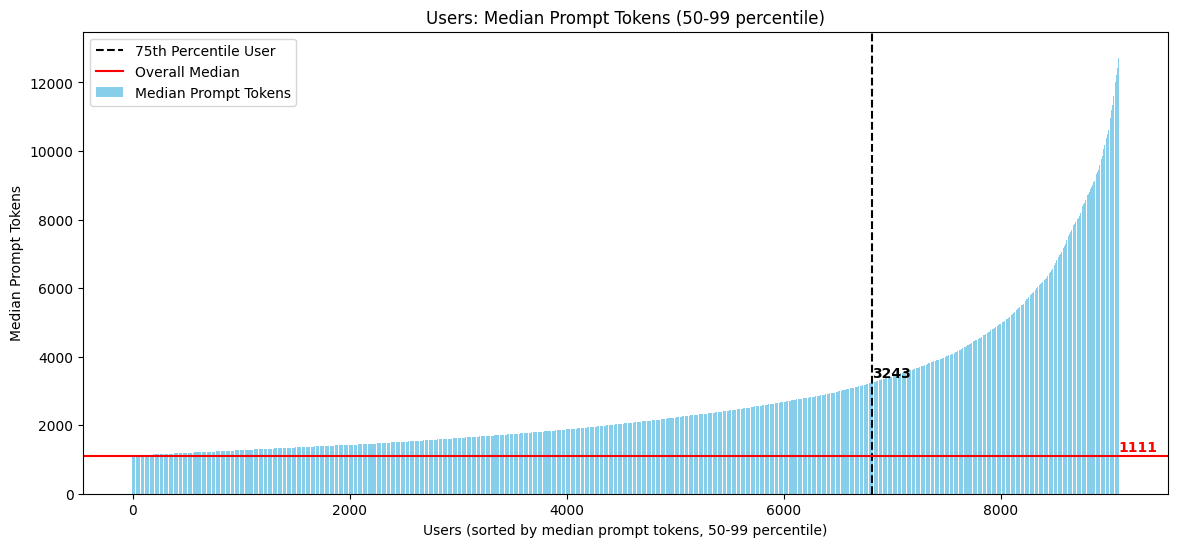

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

perc = 75  # percentile to mark

# --- Aggregate per user across all days ---
df_user = df.groupby('end_user').agg(
    median_prompt_tokens=('prompt_tokens', 'median')
).reset_index()

# --- Compute 50th and 99th percentiles ---
p50 = np.percentile(df_user['median_prompt_tokens'], 50)
p99 = np.percentile(df_user['median_prompt_tokens'], 99)

# --- Filter to 50th-99th percentile ---
df_filtered = df_user[
    (df_user['median_prompt_tokens'] >= p50) & 
    (df_user['median_prompt_tokens'] <= p99)
].copy()

# --- Sort by median prompt tokens ---
df_filtered_sorted = df_filtered.sort_values('median_prompt_tokens').reset_index(drop=True)

# --- Compute adjustable percentile ---
percentile_value = np.percentile(df_filtered_sorted['median_prompt_tokens'], perc)
idx_percentile = int(perc * len(df_filtered_sorted) / 100.0)

# --- Compute overall median of all users ---
median_all = np.median(df_user['median_prompt_tokens'])

print(f"{perc}th percentile of median prompt tokens per user: {percentile_value}")
print(f"Overall median of median prompt tokens per user: {median_all}")

# --- Plot bar ---
plt.figure(figsize=(14,6))
plt.bar(range(len(df_filtered_sorted)), df_filtered_sorted['median_prompt_tokens'],
        color='skyblue', label='Median Prompt Tokens')

# --- Percentile vertical line ---
plt.axvline(x=idx_percentile, color='black', linestyle='--', label=f'{perc}th Percentile User')

# --- Annotate percentile value ---
plt.text(idx_percentile + 1, percentile_value * 1.02, f"{int(percentile_value)}", 
         rotation=0, verticalalignment='bottom', color='black', fontweight='bold')

# --- Median horizontal line ---
plt.axhline(y=median_all, color='red', linestyle='-', label='Overall Median')
plt.text(len(df_filtered_sorted)-1, median_all*1.02, f"{int(median_all)}", 
         rotation=0, verticalalignment='bottom', color='red', fontweight='bold')

plt.xlabel("Users (sorted by median prompt tokens, 50-99 percentile)")
plt.ylabel("Median Prompt Tokens")
plt.title("Users: Median Prompt Tokens (50-99 percentile)")
plt.legend()
plt.show()


75th percentile of median daily requests: 5.0
Overall median of median daily requests: 2.0


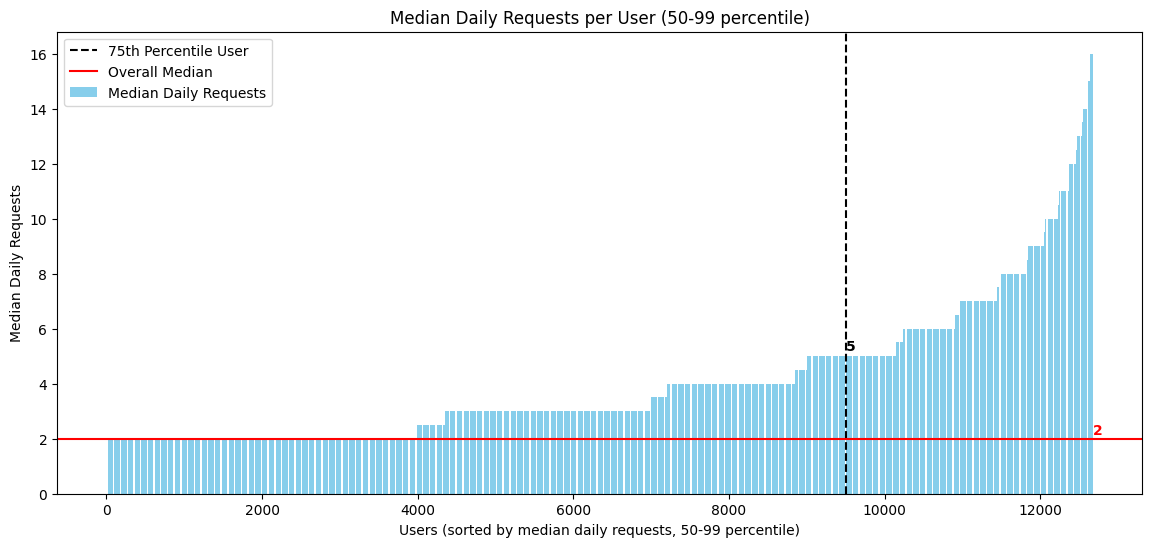

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

perc = 75  # percentile to mark on the plot

# --- Treat each user per day as a new user ---
df['date'] = df['startTime'].dt.date
df_daily_user = df.groupby(['end_user', 'date']).agg(
    daily_requests=('prompt_tokens', 'count')  # number of prompts = daily requests
).reset_index()

# --- Compute median daily requests per user ---
user_median_requests = df_daily_user.groupby('end_user')['daily_requests'].median().reset_index()
user_median_requests.rename(columns={'daily_requests':'median_daily_requests'}, inplace=True)

# --- Compute 50th and 99th percentiles ---
p50 = np.percentile(user_median_requests['median_daily_requests'], 50)
p99 = np.percentile(user_median_requests['median_daily_requests'], 99)

# --- Filter to 50th-99th percentile ---
df_filtered = user_median_requests[
    (user_median_requests['median_daily_requests'] >= p50) &
    (user_median_requests['median_daily_requests'] <= p99)
]

# --- Sort by median daily requests ---
df_filtered_sorted = df_filtered.sort_values('median_daily_requests').reset_index(drop=True)

# --- Compute adjustable percentile ---
percentile_value = np.percentile(df_filtered_sorted['median_daily_requests'], perc)
idx_percentile = int(perc * len(df_filtered_sorted) / 100.0)

# --- Compute overall median of all users ---
median_all = np.median(user_median_requests['median_daily_requests'])

print(f"{perc}th percentile of median daily requests: {percentile_value}")
print(f"Overall median of median daily requests: {median_all}")

# --- Plot bar ---
plt.figure(figsize=(14,6))
plt.bar(range(len(df_filtered_sorted)), df_filtered_sorted['median_daily_requests'],
        color='skyblue', label='Median Daily Requests')

# --- Percentile vertical line ---
plt.axvline(x=idx_percentile, color='black', linestyle='--', label=f'{perc}th Percentile User')

# --- Annotate percentile value ---
plt.text(idx_percentile + 1, percentile_value * 1.02, f"{int(percentile_value)}", 
         rotation=0, verticalalignment='bottom', color='black', fontweight='bold')

# --- Median horizontal line ---
plt.axhline(y=median_all, color='red', linestyle='-', label='Overall Median')
plt.text(len(df_filtered_sorted)-1, median_all*1.02, f"{int(median_all)}", 
         rotation=0, verticalalignment='bottom', color='red', fontweight='bold')

plt.xlabel("Users (sorted by median daily requests, 50-99 percentile)")
plt.ylabel("Median Daily Requests")
plt.title("Median Daily Requests per User (50-99 percentile)")
plt.legend()
plt.show()


### User 

So our stress test user has $5$ prompts per day, and their prompt has $3500$ tokens. The prompt tokens we will use as the median for prompt token distribution

### Prompt and Completion token Distributions

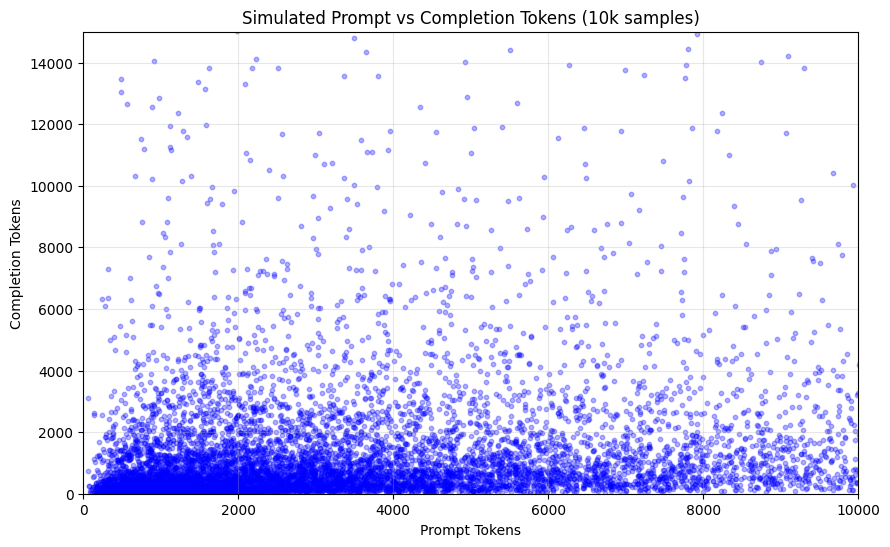

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# --- Parameters ---
sigma_prompt = 1.08
median_prompt = 3500  # median for prompt tokens
n_samples = 10000

# --- Sample prompt tokens ---
prompt_dist = lognorm(s=sigma_prompt, loc=0, scale=median_prompt)
prompt_samples = prompt_dist.rvs(size=n_samples)

# --- Compute completion token parameters from prompt tokens ---
# Formulas given:
# sigma_completion = max(-0.145*log(x) + 2.4, 0.01)
# log(mu_completion) = min(0.42*log(x) + 3.2)
sigma_completion = np.maximum(-0.145*np.log(prompt_samples) + 2.4, 0.01)
mu_completion = np.minimum(0.42*np.log(prompt_samples) + 3.2, np.inf)  # no upper limit specified

# --- Compute scale parameter for scipy lognorm (scale = exp(mu)) ---
scale_completion = np.exp(mu_completion)

# --- Sample one completion token per prompt token ---
completion_samples = lognorm(s=sigma_completion, scale=scale_completion).rvs()

# --- Scatter plot ---
plt.figure(figsize=(10,6))
plt.scatter(prompt_samples, completion_samples, alpha=0.3, s=10, color='blue')
plt.xlabel("Prompt Tokens")
plt.ylabel("Completion Tokens")
plt.title("Simulated Prompt vs Completion Tokens (10k samples)")
plt.xlim(0, 10000)  # as requested, limit prompt tokens
plt.ylim(0, 15000)
plt.grid(alpha=0.3)
plt.show()


## Whole Userbase behavior
$\textbf{Assume:}$

median prompt tokens is $3500$ using lognormal distribution

Completion tokens follows lognormal distribution, where $x$ is the sampled prompt tokens:

$\sigma = \max(-0.145*\log(x)  + 2.4,0.01)$

$\log(\mu) = \min(0.42*\log(x) + 3.2)$

The daily usage trend is:

$peak\_hour = 12$ so $loc = 2*pi*peak\_hour/24$

$\kappa = 0.65$
 
Assume we have X = 5000 users, and each does 5 prompts the stress day





C:\Users\lukas\AppData\Local\Temp\ipykernel_3080\859235086.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['hour'] = df_day['startTime'].dt.hour


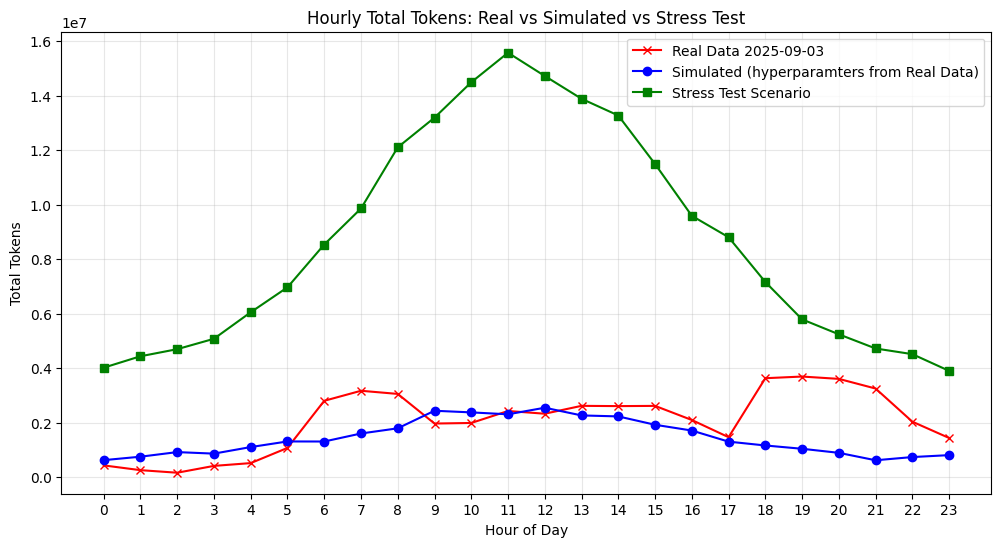

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, vonmises

# --- Pick the day for comparison ---
df['startTime'] = pd.to_datetime(df['startTime'])
df['date'] = df['startTime'].dt.date
df_day = df[df['date'] == pd.to_datetime('2025-09-03').date()]

# --- Real data stats for simulation ---
n_users_real = df_day['end_user'].nunique()
prompts_per_user_real = df_day.groupby('end_user')['prompt_tokens'].count().median()
median_prompt_real = df_day.groupby('end_user')['prompt_tokens'].median().median()
total_prompts_real = int(n_users_real * prompts_per_user_real)

# --- Simulation parameters (real scenario) ---
sigma_prompt = 1.08
prompt_dist_real = lognorm(s=sigma_prompt, scale=median_prompt_real)
prompt_samples_real = prompt_dist_real.rvs(size=total_prompts_real)

# --- Completion tokens for real scenario ---
sigma_completion_real = np.maximum(-0.145*np.log(prompt_samples_real) + 2.4, 0.01)
mu_completion_real = np.minimum(0.42*np.log(prompt_samples_real) + 3.2, np.inf)
scale_completion_real = np.exp(mu_completion_real)
completion_samples_real = lognorm(s=sigma_completion_real, scale=scale_completion_real).rvs()
total_tokens_real_sim = prompt_samples_real + completion_samples_real

# --- Stress test scenario ---
n_users_stress = 20000
prompts_per_user_stress = 3
median_prompt_stress = 1200
total_prompts_stress = n_users_stress * prompts_per_user_stress

prompt_dist_stress = lognorm(s=sigma_prompt, scale=median_prompt_stress)
prompt_samples_stress = prompt_dist_stress.rvs(size=total_prompts_stress)

sigma_completion_stress = np.maximum(-0.145*np.log(prompt_samples_stress) + 2.4, 0.01)
mu_completion_stress = np.minimum(0.42*np.log(prompt_samples_stress) + 3.2, np.inf)
scale_completion_stress = np.exp(mu_completion_stress)
completion_samples_stress = lognorm(s=sigma_completion_stress, scale=scale_completion_stress).rvs()
total_tokens_stress = prompt_samples_stress + completion_samples_stress

# --- Assign prompt times using von Mises distribution (same for both scenarios) ---
peak_hour = 12
kappa = 0.65
loc_rad = 2 * np.pi * peak_hour / 24

angles_real = vonmises(kappa=kappa, loc=loc_rad).rvs(size=total_prompts_real)
hours_sim_real = (angles_real % (2*np.pi)) * 24 / (2*np.pi)

angles_stress = vonmises(kappa=kappa, loc=loc_rad).rvs(size=total_prompts_stress)
hours_sim_stress = (angles_stress % (2*np.pi)) * 24 / (2*np.pi)

# --- Aggregate total tokens per hour ---
bins = np.arange(0, 25, 1)
total_tokens_per_hour_real = [total_tokens_real_sim[(hours_sim_real >= bins[i]) & (hours_sim_real < bins[i+1])].sum() for i in range(24)]
total_tokens_per_hour_stress = [total_tokens_stress[(hours_sim_stress >= bins[i]) & (hours_sim_stress < bins[i+1])].sum() for i in range(24)]

# --- Aggregate total tokens per hour in the real data ---
df_day['hour'] = df_day['startTime'].dt.hour
total_tokens_real_data = df_day.groupby('hour').agg(
    total_tokens=('prompt_tokens', 'sum')
).reindex(range(24), fill_value=0)['total_tokens'].values

# --- Plot comparison ---
plt.figure(figsize=(12,6))
plt.plot(range(24), total_tokens_real_data, label='Real Data 2025-09-03', color='red', marker='x')
plt.plot(range(24), total_tokens_per_hour_real, label='Simulated (hyperparamters from Real Data)', color='blue', marker='o')
plt.plot(range(24), total_tokens_per_hour_stress, label='Stress Test Scenario', color='green', marker='s')

plt.xlabel('Hour of Day')
plt.ylabel('Total Tokens')
plt.title(f'Hourly Total Tokens: Real vs Simulated vs Stress Test')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()
